In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_experiments.library.tomography import ProcessTomography, MitigatedProcessTomography
# from qiskit import QuantumCircuit
# from qiskit_ibm_runtime.fake_provider import FakeKyoto
# from qiskit_aer import AerSimulator
# from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import Chi, Choi, Kraus, SuperOp
import numpy as np
# from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
from gen_funcs import *
from post_proc_funcs import *
import pickle
import matplotlib.pyplot as plt

In [42]:
def compute_Drhp2(intmdt_map_ls, base_circ_time=90):
    ''' compute normalized non-markovianity
    inputs:
    intmdt_map_ls: list of intermediate maps
    base_circ_time: duration of the shortest circuit

    output: non-markovianity of the map built out of the list of intermediate
    maps
    '''
    gt = []
    for map in intmdt_map_ls:
        gt.append((np.linalg.norm(Choi(map), ord=1) - 1))
        # print((np.linalg.norm(Choi(map), ord=1) - 1))
    Nrhp = sum(gt)
    Drhp = 1 - np.e ** (-Nrhp)
    return Drhp


def alt_compute_Drhp(intmdt_map_ls, base_circ_time=90):
    ''' compute normalized non-markovianity
    inputs:
    intmdt_map_ls: list of intermediate maps
    base_circ_time: duration of the shortest circuit

    output: non-markovianity of the map built out of the list of intermediate
    maps
    '''
    gt = []
    for map in intmdt_map_ls:
        gt.append(np.tanh(np.linalg.norm(Choi(map), ord='nuc') - 1))
        # print((np.linalg.norm(Choi(map), ord=1) - 1))
    Nrhp = sum(gt)
    # print(Nrhp)
    try:
        Drhp = Nrhp / (len(intmdt_map_ls))
    except:
        Drhp = Nrhp
    return Drhp, gt

def compute_intermediate_maps(final_evo_list, pseudo_inv=False):
    ''' computes the last intermediate map from the list of intermediate maps
    inputs:
    phi_N: the last map of the sequence
    intermediate_list: list of intermediate maps

    output: the last intermediate map
    '''
    dim = 2 ** (final_evo_list[0].num_qubits * 2)
    # first compute the intermediate maps 
    intermediate_maps = []
    intermediate_maps.append(final_evo_list[0])
    for i in range(1, len(final_evo_list)):
        curr_applied_inv = np.identity(dim)
        for j in range(i):
            curr_applied_inv = curr_applied_inv @ np.linalg.pinv(intermediate_maps[j])
        intermediate_maps.append(final_evo_list[i] @ curr_applied_inv)

    return intermediate_maps

In [2]:
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.backend("ibm_kyoto")

In [10]:
circ_ls_1q = gen_delay_circ_ls(1, 127, 12.7)
circ_ls_2q = gen_delay_circ_ls(2, 63, 12.6)
qubit_ls_1q = gen_qubit_ls(127, 1, repeat=False)
qubit_ls_2q = gen_qubit_ls(126, 2, repeat=False)
parallel_exp_idle_1q_mitigated = parallel_exp_1q2q(qc_ls=circ_ls_1q, backend=backend, qubit_ls=qubit_ls_1q, mitigation=1)
parallel_exp_idle_2q_mitigated = parallel_exp_1q2q(qc_ls=circ_ls_2q, backend=backend, qubit_ls=qubit_ls_2q, mitigation=1)

In [9]:
parallel_1q_mitigated_result = parallel_exp_idle_1q_mitigated.run(backend=backend)

In [11]:
parallel_2q_mitigated_result = parallel_exp_idle_2q_mitigated.run(backend=backend)

In [35]:
with open('ss1q_idle_origdata.pickle', 'wb') as handle:
    pickle.dump(parallel_1q_mitigated_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('ss2q_idle_origdata.pickle', 'wb') as handle:
    pickle.dump(parallel_2q_mitigated_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [37]:
parallel_1q_idle_mitigated_superop_ls = extract_channel(parallel_1q_mitigated_result, vectorization=1)
with open('ss1q_idle.pickle', 'wb') as handle:
    pickle.dump(parallel_1q_idle_mitigated_superop_ls, handle, protocol=pickle.HIGHEST_PROTOCOL)

parallel_2q_idle_mitigated_superop_ls = extract_channel(parallel_2q_mitigated_result, vectorization=1)
with open('ss2q_idle.pickle', 'wb') as handle:
    pickle.dump(parallel_2q_idle_mitigated_superop_ls, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [48]:
intmdt_maps_1q_idle = compute_intermediate_maps(parallel_1q_idle_mitigated_superop_ls)
intmdt_maps_2q_idle = compute_intermediate_maps(parallel_2q_idle_mitigated_superop_ls)
# Drhp_1q_idle = compute_Drhp(intmdt_maps_1q_idle)
# Drhp_2q_idle = compute_Drhp(intmdt_maps_2q_idle)

In [44]:
Drhp_1q_idle_ls = []

for i in range(0, len(parallel_1q_idle_mitigated_superop_ls)):
    curr_Drhp = alt_compute_Drhp(intmdt_maps_1q_idle[0: i])[0]
    # print(curr_Drhp)
    Drhp_1q_idle_ls.append(curr_Drhp)

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/bx/s6dzkvjx7bj_6cw_x8xsvkdr0000gn/T/ipykernel_82787/4177653315.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('time ($\mu$s)')


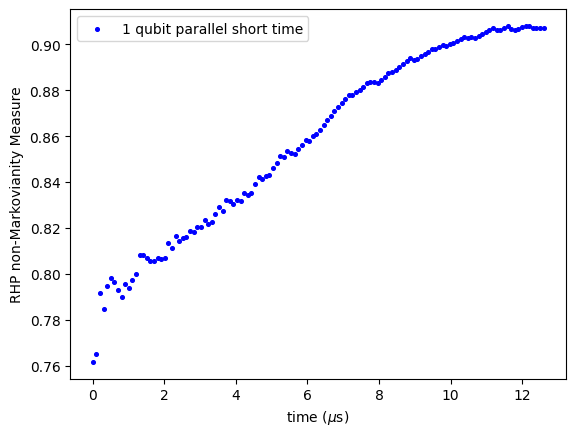

In [59]:
ssx = np.linspace(0, 12.6, 126)
plt.scatter(ssx, Drhp_1q_idle_ls[1:], s=7, label='1 qubit parallel short time', color='blue')
plt.xlabel('time ($\mu$s)')
plt.ylabel('RHP non-Markovianity Measure')
plt.legend()
plt.savefig(fname='ss1q.png', dpi=400)

In [50]:
Drhp_2q_idle_ls = []

for i in range(0, len(parallel_2q_idle_mitigated_superop_ls)):
    curr_Drhp = alt_compute_Drhp(intmdt_maps_2q_idle[0: i])[0]
    # print(curr_Drhp)
    Drhp_2q_idle_ls.append(curr_Drhp)

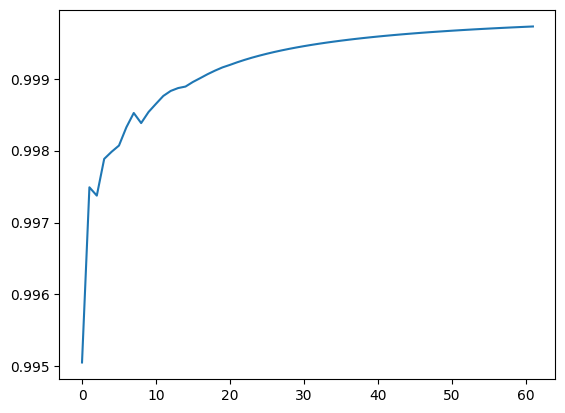

In [53]:
plt.plot(Drhp_2q_idle_ls[1:])